**Predizione di uno "score" di recupero per atleti in base alle abitudini, dati biometrici e performance**

Progetto di Programmazione di Applicazioni Data Intensive a.a. 2025/26:
Alan Barzanti, Marco Mondardini

L'obiettivo di questo progetto è predire il Recovery_Score giornaliero di un atleta, ovvero un indice che sintetizza lo stato di recupero psicofisico dell'atleta, a partire dalle condizioni di allenamento, sonno, stress e dai biomarcatori rilevati nella stessa giornata.

Il dataset utilizzato è Athlete Recovery & Biometric Performance Dataset, disponibile su Kaggle, contiene osservazioni giornaliere di 300 atleti monitorati per 28 giorni tramite dispositivi wearable. Le istanze sono circa 8000 e le variabili 19. Ogni riga rappresenta il monitoraggio di un atleta in un dato giorno, e ogni colonna una caratteristica relativa al suo stato fisico, psicologico o al carico di allenamento sostenuto.

**Introduzione**

Procediamo al caricamento delle librerie fondamendali e del dataset:

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

import os.path

file = "./athlete_recovery_synthetic.csv";
if not os.path.exists(file):
    print("The dataset is missing.");

data = pd.read_csv(file);

Prima di tutto analizziamo il significato di ogni colonna:
- Identificatori e variabili temporali, non utilizzate come predittori nel modello:
    - `Athlete_ID` — Identificativo univoco dell' atleta
    - `Day` — Il giorno del mese, da 1 a 28.
    - `Day_of_Week` — Giorno della settimana da 1 a 7 .
    - `Week` — Numero della settimana del mese da 1 a 4.
- Profilo anagrafico e sportivo,  caratteristiche relativamente stabili dell'atleta:
    - `Age` — Età dell'atleta *(numerica continua)*, espressa in anni, da 18 a 41.
    - `Gender` — Genere dell'atleta *(categorica: Male / Female / Non-binary)*.
    - `Sport_Type` — Tipo di sport dell'atleta *(categorica: Team Sport, Endurance, Strength)*.
    - `Training_Type` — Tipo specifico dell'allenamento *(categorica: HIIT, Cardio, Rest, Strength)*.
- Carico di allenamento, variabili che descrivono l'intensità dello sforzo quotidiano:
    - `Training_Duration_Min` — Durata dell'allenamento in minuti.
    - `Training_Intensity` — Intensità dell'allenamento, soggettiva o misurata, in un range da 1.0 a 10.0.
- Stile di vita e stato psicologico:
    - `Sleep_Duration_Hours` — Ore di sonno della notte precedente all'allenamento *(numerica continua)*.
    - `Caffeine_Intake_mg` — Caffeina assunta durante il giorno in milligrammi.
    - `Stress_Level` — Livello di stress *(categorica ordinale: Low / Medium / High)*.
- Biomarcatori fisiologici e soggettivi, indicatori dello stato del corpo:
    - `Resting_Heart_Rate` — Battiti del cuore a riposo in battiti per minuto (BPM).
    - `HRV_ms` — Variabilità della frequenza cardiaca misurata in millisecondi.
    - `Mood_Score` — Livello del morale da 1.0 a 10.0.
    - `Muscle_Soreness` — Livello di dolore muscolare da 1.0 a 10.0.
    - `Energy_Level` — Livello di energia percepita da 1.0 a 10.0
- Variabile target:
    - `Recovery_Score` — Punteggio complessivo da 0.0 a 100.0 che indica la condizione fisica generale dell'atleta.

In [9]:
data.head(1)

,Athlete_ID,Day,Day_of_Week,Week,Age,Gender,Sport_Type,Training_Type,Training_Duration_Min,Training_Intensity,Sleep_Duration_Hours,Caffeine_Intake_mg,Stress_Level,Resting_Heart_Rate,HRV_ms,Mood_Score,Muscle_Soreness,Energy_Level,Recovery_Score
0,1000,1,1,1,28,Male,Team Sport,HIIT,46,7.9,7.7,270,High,59,75,4.3,4.8,5.9,51.1


In [10]:
data.info(verbose=False, memory_usage="deep");

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8379 entries, 0 to 8378
Columns: 19 entries, Athlete_ID to Recovery_Score
dtypes: float64(6), int64(9), object(4)
memory usage: 2.7 MB


Come possiamo vedere al momento l'utilizzo della memoria è di 2.7MB, ma possiamo ottimizzarlo:

In [11]:
data['Gender'] = data['Gender'].astype("category")
data['Sport_Type'] = data['Sport_Type'].astype("category")
data['Training_Type'] = data['Training_Type'].astype("category")
data['Stress_Level'] = data['Stress_Level'].astype("category")
data = data.drop(columns=["Athlete_ID"])

In [12]:
data.info(verbose=False, memory_usage="deep");

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8379 entries, 0 to 8378
Columns: 18 entries, Day to Recovery_Score
dtypes: category(4), float64(6), int64(8)
memory usage: 950.7 KB


**Analisi esplorativa dei dati:**

Per prima cosa osserviamo come sono distribuiti i punteggi:

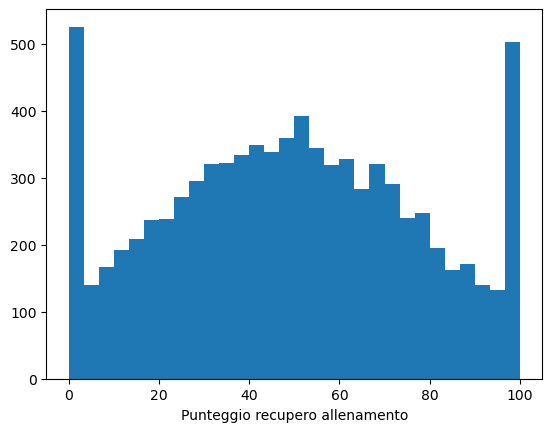

In [110]:
plt.hist(data["Recovery_Score"], bins=30)
plt.xlabel("Punteggio recupero allenamento")
plt.show()

Notiamo una distribuzione gaussiana con un picco intorno al valore 55 per poi scendere di nuovo. Tuttavia i picchi anomali su 0 e 100 potrebbero essere problematici: un modello di regressione standard potrebbe fare fatica a predire esattamente questi estremi, e le metriche come MSE potrebbero esserne influenzate.

Analizziamo le statistiche generali del dataset:

In [172]:
data.describe()

,Day,Day_of_Week,Week,Age,Training_Duration_Min,Training_Intensity,Sleep_Duration_Hours,Caffeine_Intake_mg,Resting_Heart_Rate,HRV_ms,Mood_Score,Muscle_Soreness,Energy_Level,Recovery_Score
count,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000,8378.000000,7775.000000,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000
mean,14.497076,3.998329,2.499821,25.860962,52.789712,6.211506,7.498842,185.348132,57.202888,74.126507,5.177109,5.161953,3.273087,49.061356
std,8.078044,2.000417,1.117941,4.531092,21.357704,2.368960,0.693790,112.850208,5.790991,13.981632,1.210072,2.127583,1.679100,27.926347
min,1.000000,1.000000,1.000000,18.000000,10.000000,1.000000,5.000000,0.000000,38.000000,22.000000,1.000000,1.000000,1.000000,0.000000
25%,8.000000,2.000000,2.000000,23.000000,36.000000,4.900000,7.000000,126.000000,53.000000,64.000000,4.400000,3.600000,2.000000,27.800000
50%,14.000000,4.000000,2.000000,26.000000,56.000000,6.600000,7.500000,212.000000,58.000000,74.000000,5.200000,5.200000,3.100000,48.900000
75%,21.000000,6.000000,3.000000,28.000000,69.000000,7.900000,8.000000,268.000000,61.000000,84.000000,6.000000,6.700000,4.300000,69.900000
max,28.000000,7.000000,4.000000,41.000000,115.000000,10.000000,9.500000,400.000000,81.000000,115.000000,9.500000,10.000000,10.000000,100.000000


Il dataset contiene 8379 osservazioni totali, corrispondenti a 300 atleti monitorati per 28 giorni ciascuno. La variabile target Recovery_Score presenta una media di circa 49 e una deviazione standard di 28, confermando la distribuzione ampia osservata nell'istogramma. HRV_ms varia tra 22 e 115 con media 74, mentre Caffeine_Intake_mg mostra un'elevata variabilità con deviazione standard di 112 rispetto a una media di 185. Il campione è prevalentemente giovane, con età compresa tra 18 e 41 anni e media di circa 26. Si segnala la presenza di valori nulli in Sleep_Duration_Hours (circa 600 valori mancanti) e in misura minore in Training_Intensity, che dovranno essere gestiti nella fase di preprocessing.

Osserviamo alcuni fattori che correlazione hanno con il punteggio finale:

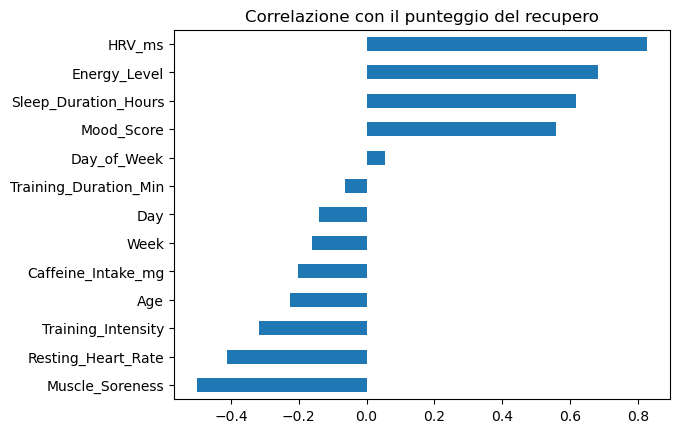

In [114]:
df_numeric = data.select_dtypes(include="number")
corr = df_numeric.corr()["Recovery_Score"].drop("Recovery_Score").sort_values()
corr.plot(kind="barh")
plt.title("Correlazione con il punteggio del recupero")
plt.show()

Notiamo che l'HRV è la variabile con la più alta correlazione positiva, mentre l'indolenzimento muscolare ha l'impatto maggiormente negativo.
Il sonno e il morale mostrano correlazioni positive significative, confermando il loro ruolo fondamentale nel recupero.
Possiamo inoltre notare che l'intensità dell'allenamento e l'età influenzano negativamente il recupero dell'atleta.

Proviamo ad analizzare tramite dei grafici a dispersione le variabili con una correlazione maggiore:

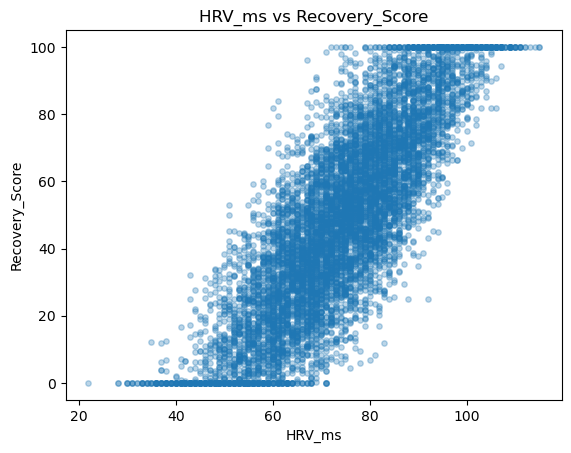

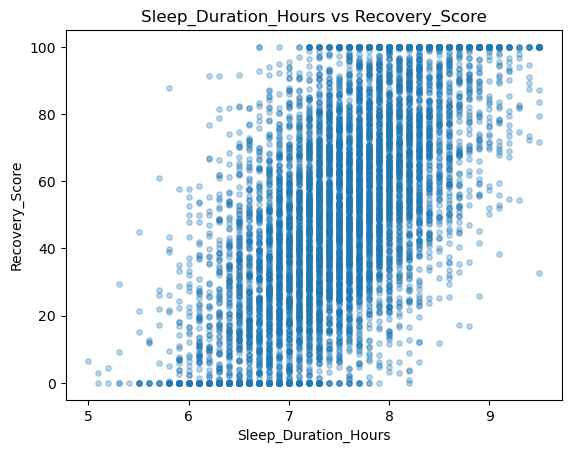

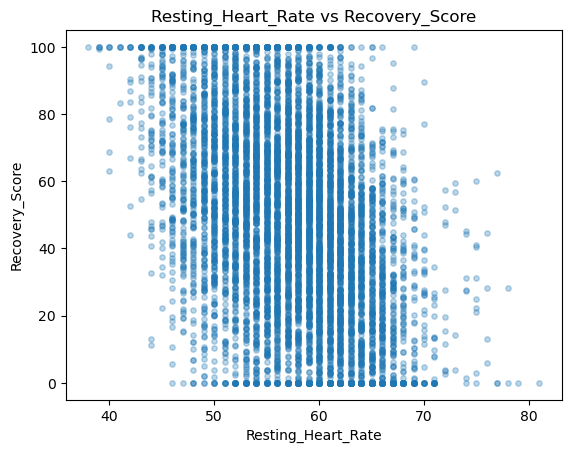

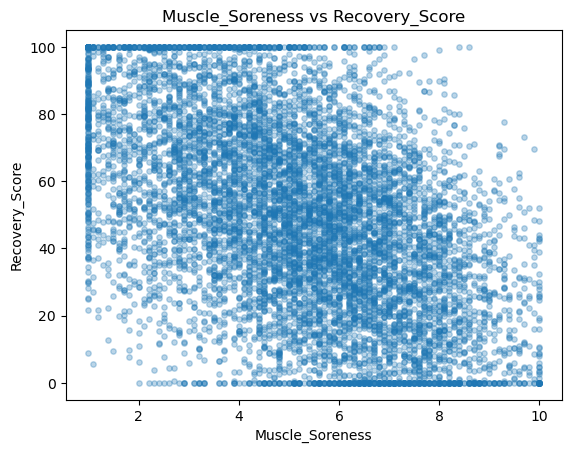

In [157]:
for col in ["HRV_ms", "Sleep_Duration_Hours", "Resting_Heart_Rate", "Muscle_Soreness"]:
    plt.scatter(data[col], data["Recovery_Score"], alpha=0.3, s=15)
    plt.xlabel(col)
    plt.ylabel("Recovery_Score")
    plt.title(f"{col} vs Recovery_Score")
    plt.show()

Lo scatter plot di HRV_ms mostra la relazione più chiara e quasi lineare con il Recovery Score: al crescere della variabilità cardiaca il punteggio aumenta in modo consistente, con poca dispersione. Sleep_Duration_Hours e Resting_Heart_Rate mostrano invece una relazione molto più rumorosa, i punti sono dispersi verticalmente per ogni valore del predittore, suggerendo che queste variabili da sole non sono sufficienti a determinare il recovery, ma contribuiscono in combinazione con le altre. Confermano comunque il segno atteso: più sonno tende ad associarsi a recovery più alto, frequenza cardiaca a riposo più alta a recovery più basso.
Per quanto riguarda Muscle_Soreness la relazione è sì negativa, ma molto rumorosa: all'aumentare del dolore muscolare il punteggio tende a calare, ma la dispersione verticale è elevata per tutti i valori del predittore. Questo indica che il dolore muscolare contribuisce negativamente al recupero, ma da solo non è determinante, il suo effetto emerge principalmente in combinazione con le altre variabili.

Utilizziamo dei grafici a torta per visualizzare la distribuzione delle variabili categoriche:

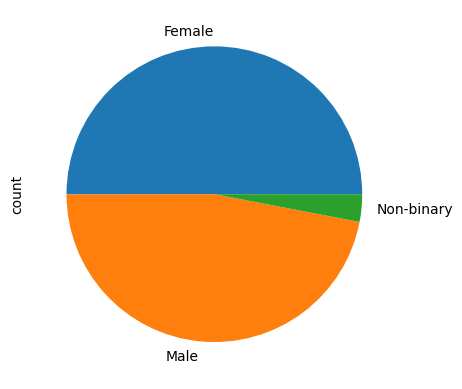

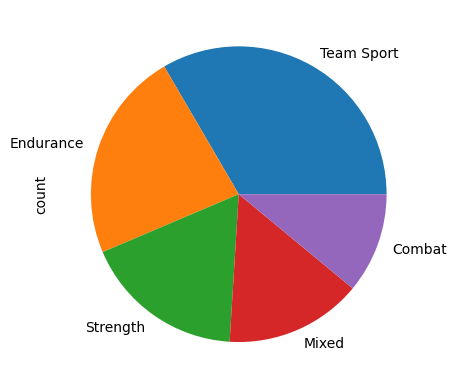

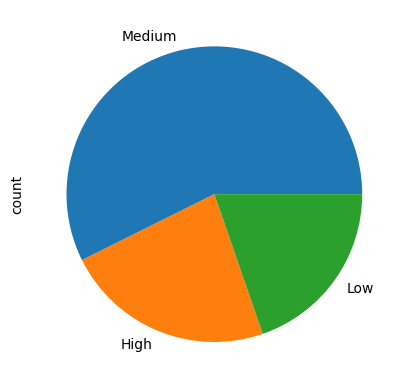

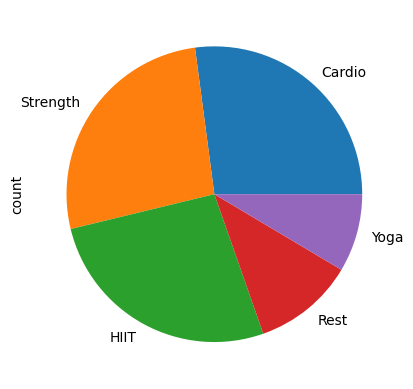

In [165]:
gender = data["Gender"].value_counts()
gender.plot.pie()
plt.show()

gender = data["Sport_Type"].value_counts()
gender.plot.pie()
plt.show()

gender = data["Stress_Level"].value_counts()
gender.plot.pie()
plt.show()

gender = data["Training_Type"].value_counts()
gender.plot.pie()
plt.show()

I grafici a torta mostrano una distribuzione sostanzialmente bilanciata tra le categorie. Per Sport_Type le cinque categorie sono rappresentate in proporzioni simili, senza una dominanza particolare di alcun gruppo. Per Stress_Level la categoria più rappresentata è Medium, seguita da Low e poi High, la distribuzione è ragionevolmente equilibrata, nessuna categoria è quasi assente. Training_Type mostra una distribuzione equilibrata tra Cardio, Strength, HIIT e Yoga, con Rest che occupa una fetta minoritaria, coerente con il fatto che i giorni di riposo sono meno frequenti dei giorni di allenamento. L'assenza di classi fortemente sbilanciate è un risultato positivo.

Le variabili temporali Day, Day_of_Week e Week non rappresentano caratteristiche intrinseche dell'atleta, ma dipendono dalla specifica finestra di monitoraggio. Un modello che le includesse imparerebbe pattern legati alla struttura del dataset piuttosto che al recupero reale. Tuttavia prima di rimuoverle verifichiamo empiricamente che non esistano pattern temporali significativi che leghino queste variabili a Recovery Score. In questo senso il grafico di correlazione ci mostra già delle relazioni trascurabili, ma verifichiamolo meglio:

Per prima cosa osserviamo l'andamento del Recovery Score rispetto ai giorni totali:

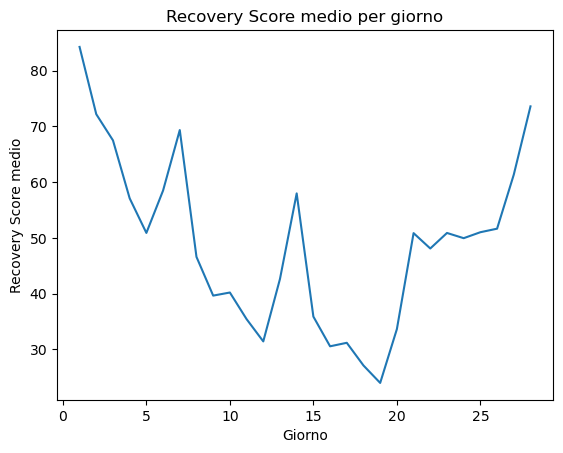

In [118]:
daily_avg = data.groupby('Day')['Recovery_Score'].mean()
daily_avg.plot()
plt.title('Recovery Score medio per giorno')
plt.xlabel('Giorno')
plt.ylabel('Recovery Score medio')
plt.show()

Il grafico mostra oscillazioni irregolari senza un trend chiaro o un pattern ciclico riconoscibile. Non si vede né un calo progressivo da accumulo di fatica, né un effetto settimanale sistematico.

Proviamo ora ad effettuare la stessa verifica ma considerando i giorni della settimana:

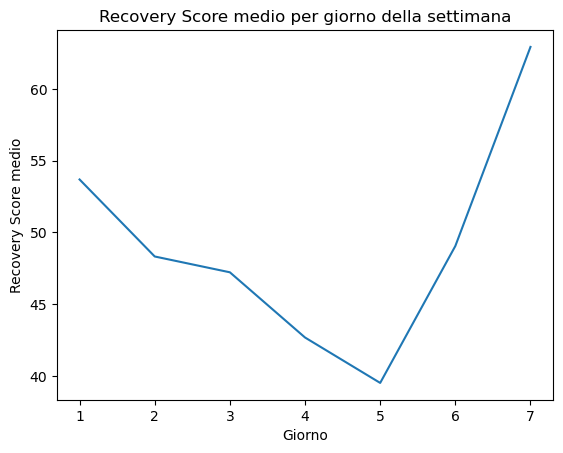

In [122]:
daily_avg = data.groupby('Day_of_Week')['Recovery_Score'].mean()
daily_avg.plot()
plt.title('Recovery Score medio per giorno della settimana')
plt.xlabel('Giorno')
plt.ylabel('Recovery Score medio')
plt.show()

Questo grafico è più interessante in quanto mostra un pattern chiaro: il Recovery Score cala progressivamente da Lunedì a Venerdì, per poi risalire nettamente nel weekend. Un effetto fisiologicamente sensato, che renderebbe il giorno della settimana un dato utile per predire la variabile target. Tuttavia sorge il dubbio che questo sia dato dal fatto che nel dataset i giorni di riposo siano inseriti sistematicamente nel weekend. Se così fosse allora questo effetto sarebbe già catturato dal modello grazie alla variabile Training_Type. Procediamo quindi con questa verifica:

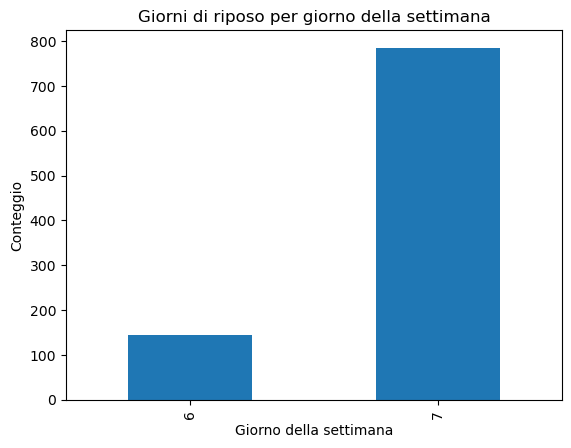

In [127]:
rest_by_day = data[data['Training_Type'] == 'Rest'].groupby('Day_of_Week').size()
rest_by_day.plot(kind='bar')
plt.title('Giorni di riposo per giorno della settimana')
plt.xlabel('Giorno della settimana')
plt.ylabel('Conteggio')
plt.show()

Come sospettavamo, tutti i giorni di riposo sono concentrati nel weekend, questo rende il dato relativo al giorno della settimana superfluo e ridondante.

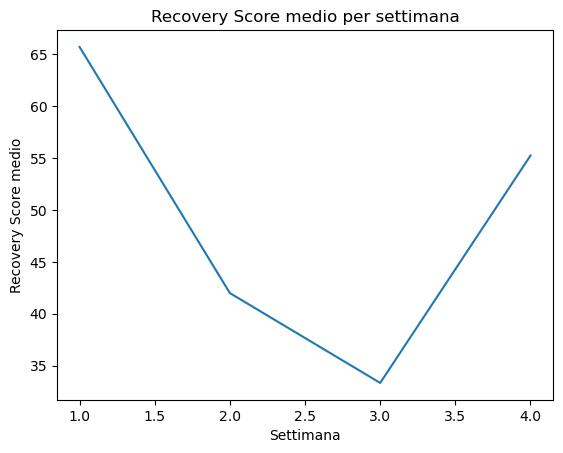

In [133]:
daily_avg = data.groupby('Week')['Recovery_Score'].mean()
daily_avg.plot()
plt.title('Recovery Score medio per settimana')
plt.xlabel('Settimana')
plt.ylabel('Recovery Score medio')
plt.show()

Questo grafico ci mostra l'andamento del Recovery Score rispetto alle settimane, tuttavia con solo 4 punti è difficile trarre conclusioni affidabili.

Alla luce delle precedenti analisi, procediamo a rimuovere Day, Day_of_Week e Week:

In [90]:
data = data.drop(columns=["Day"])
data = data.drop(columns=["Day_of_Week"])
data = data.drop(columns=["Week"])

**Preparazione dei dati**

Come prima cosa controlliamo che nel dataset non ci siano valori NaN:

In [19]:
data.isnull().sum()

Day                      0
Day_of_Week              0
Week                     0
Age                      0
Gender                   0
Sport_Type               0
Training_Type            0
Training_Duration_Min    0
Training_Intensity       0
Sleep_Duration_Hours     0
Caffeine_Intake_mg       0
Stress_Level             0
Resting_Heart_Rate       0
HRV_ms                   0
Mood_Score               0
Muscle_Soreness          0
Energy_Level             0
Recovery_Score           0
dtype: int64

Vediamo che in Training_Intensity manca un solo valore mentre in Sleep_Duration_Hours sono molteplici i valori mancanti

Riempiamo quei valori con la media della colonna corrispondente

In [20]:
data["Training_Intensity"] = data["Training_Intensity"].fillna(data["Training_Intensity"].mean())
data["Sleep_Duration_Hours"] = data["Sleep_Duration_Hours"].fillna(data["Sleep_Duration_Hours"].mean())

In [21]:
data.isnull().sum()

Day                      0
Day_of_Week              0
Week                     0
Age                      0
Gender                   0
Sport_Type               0
Training_Type            0
Training_Duration_Min    0
Training_Intensity       0
Sleep_Duration_Hours     0
Caffeine_Intake_mg       0
Stress_Level             0
Resting_Heart_Rate       0
HRV_ms                   0
Mood_Score               0
Muscle_Soreness          0
Energy_Level             0
Recovery_Score           0
dtype: int64

Come possiamo vedere ora non sono più presenti valori NaN

Ora dobbiamo rendere le variabili categoriche adatte per l'addestramento dei modelli: 
- utilizziamo One-hot encoding per Gender, Training_Type e Sport_Type
- utilizziamo un mapping per Stress_Sevel

In [23]:
data = pd.get_dummies(data, columns=["Gender", "Training_Type", "Sport_Type"], drop_first=True)

In [25]:
stress_map = {"Low": 0, "Medium": 1, "High": 2}
data["Stress_Level"] = data["Stress_Level"].map(stress_map)
data["Stress_Level"] = data["Stress_Level"].astype(int)

In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8379 entries, 0 to 8378
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Day                     8379 non-null   int64  
 1   Day_of_Week             8379 non-null   int64  
 2   Week                    8379 non-null   int64  
 3   Age                     8379 non-null   int64  
 4   Training_Duration_Min   8379 non-null   int64  
 5   Training_Intensity      8379 non-null   float64
 6   Sleep_Duration_Hours    8379 non-null   float64
 7   Caffeine_Intake_mg      8379 non-null   int64  
 8   Stress_Level            8379 non-null   int32  
 9   Resting_Heart_Rate      8379 non-null   int64  
 10  HRV_ms                  8379 non-null   int64  
 11  Mood_Score              8379 non-null   float64
 12  Muscle_Soreness         8379 non-null   float64
 13  Energy_Level            8379 non-null   float64
 14  Recovery_Score          8379 non-null   

Come posssiamo vedere ora abbiamo una colonna di tipo booleani per ogni tipo possibile delle tre variabile categoriche. Per quanto riguarda stress_level invece ora i valori low, medium e high sono diventati 0, 1 e 2.

Passiamo all'isolare la variabile target dalle feature:

In [ ]:
X = data.drop(columns=["Recovery_Score"])
y = data["grades"]